In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
iris = load_iris()

In [3]:
# Createing dataframe
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
# Select features
X = df.iloc[:, :4]


In [5]:
# Feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
# Elbow Method

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

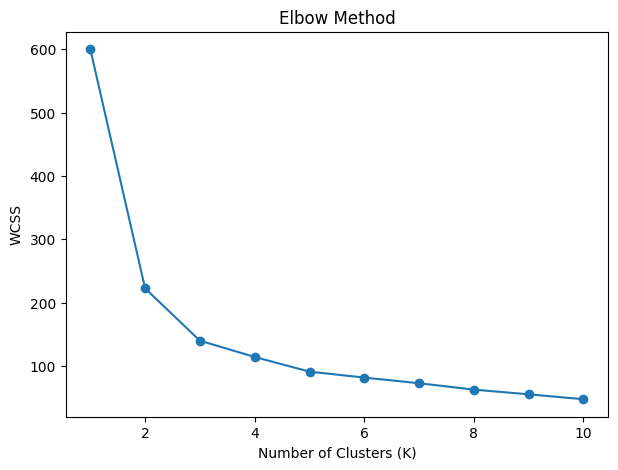

In [7]:
# Plot elbow graph
plt.figure(figsize=(7,5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


In [8]:
# Training K-Means


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)


In [9]:
# Adding cluster labels
df['Cluster'] = clusters

<Axes: >

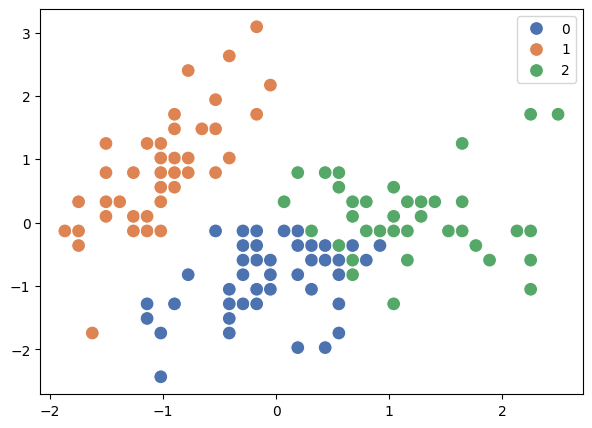

In [10]:
# Visualizing Clusters

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters,
    palette='deep',
    s=100
)

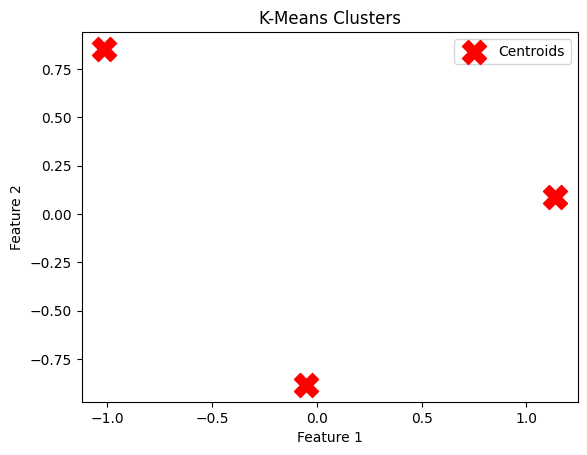

In [11]:
# Ploting centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("K-Means Clusters")

plt.legend()

plt.show()

In [12]:
# Silhouetteing Score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518635
